# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [29]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [30]:
class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def value(self):
        if self.rank in ['J', 'Q', 'K']:
            return 10
        elif self.rank == 'A':
            return 11
        else:
            return int(self.rank)

    def __str__(self):
        return f"{self.rank}{self.suit}"

In [31]:
class Shoe:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.build_shoe()
        self.shuffle()
        self.cut_card_position = int(len(self.cards) * 0.75)

    def build_shoe(self):
        ranks = ['2','3','4','5','6','7','8','9','10','J','Q','K','A']
        suits = ['H','D','C','S']
        self.cards = [Card(r, s) for r in ranks for s in suits] * self.num_decks

    def shuffle(self):
        random.shuffle(self.cards)

    def draw_card(self):
        if len(self.cards) <= self.cut_card_position:
            self.build_shoe()
            self.shuffle()
        return self.cards.pop()

In [32]:
class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def value(self):
        total = sum(card.value() for card in self.cards)
        aces = sum(1 for c in self.cards if c.rank == 'A')

        while total > 21 and aces:
            total -= 10
            aces -= 1
        return total

    def is_bust(self):
        return self.value() > 21

    def __str__(self):
        return ", ".join(str(c) for c in self.cards)

In [33]:
class BasePlayer:
    def __init__(self, name):
        self.name = name
        self.hand = Hand()

    def play(self, shoe):
        while self.hand.value() < 17:
            self.hand.add_card(shoe.draw_card())
            

In [34]:
class DealerPlayer(BasePlayer):
    def play(self, shoe):
        while self.hand.value() < 17:
            self.hand.add_card(shoe.draw_card())

In [35]:
class CountingPlayer(BasePlayer):
    def __init__(self, name, threshold=0):
        super().__init__(name)
        self.count = 0
        self.threshold = threshold

    def update_count(self, card):
        if card.rank in ['2','3','4','5','6']:
            self.count += 1
        elif card.rank in ['10','J','Q','K','A']:
            self.count -= 1

    def play(self, shoe):
        while self.hand.value() < 17:
            card = shoe.draw_card()
            self.update_count(card)
            self.hand.add_card(card)

In [36]:
class ConservativeCountPlayer(CountingPlayer):
    def play(self, shoe):
        while True:
            val = self.hand.value()
            if val >= 17:
                break
            if val >= 12 and self.count < 0:
                break
            card = shoe.draw_card()
            self.update_count(card)
            self.hand.add_card(card)

In [37]:
class BlackjackGame:
    def __init__(self):
        self.shoe = Shoe()

    def play_round(self, player, dealer):
        player.hand = Hand()
        dealer.hand = Hand()

        # initial deal
        for _ in range(2):
            player.hand.add_card(self.shoe.draw_card())
            dealer.hand.add_card(self.shoe.draw_card())

        player.play(self.shoe)
        dealer.play(self.shoe)

        p_val = player.hand.value()
        d_val = dealer.hand.value()

        if player.hand.is_bust():
            return -1
        elif dealer.hand.is_bust():
            return 1
        elif p_val > d_val:
            return 1
        elif p_val < d_val:
            return -1
        else:
            return 0

In [38]:
game = BlackjackGame()
player = CountingPlayer("Player")
dealer = DealerPlayer("Dealer")

money = 100
rounds = 0

while money > 0 and rounds < 50:
    result = game.play_round(player, dealer)
    money += result
    rounds += 1

print("Final Money:", money)

Final Money: 98


In [39]:
results = []

for _ in range(100):
    game = BlackjackGame()
    player = CountingPlayer("Player")
    dealer = DealerPlayer("Dealer")

    money = 100
    rounds = 0

    while money > 0 and rounds < 50:
        result = game.play_round(player, dealer)
        money += result
        rounds += 1

    results.append(money)

print("Average:", np.mean(results))
print("Std Dev:", np.std(results))
print("Profit Probability:", sum(r > 100 for r in results)/len(results))

Average: 96.05
Std Dev: 7.1405531998578375
Profit Probability: 0.3


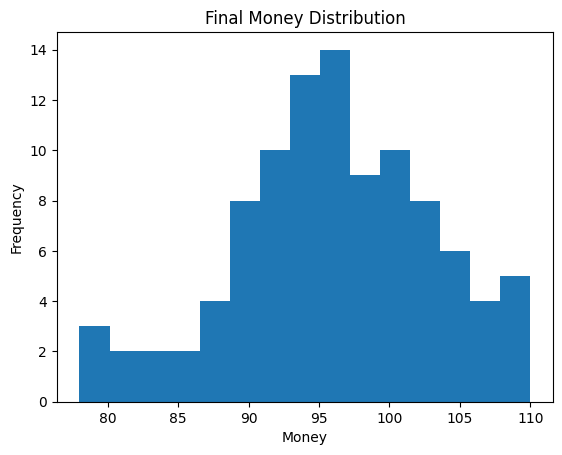

In [40]:
plt.hist(results, bins=15)
plt.title("Final Money Distribution")
plt.xlabel("Money")
plt.ylabel("Frequency")
plt.show()

In [41]:
thresholds = range(-5, 6)
avg_results = []

for t in thresholds:
    res = []
    for _ in range(50):
        game = BlackjackGame()
        player = CountingPlayer("Player", threshold=t)
        dealer = DealerPlayer("Dealer")

        money = 100
        rounds = 0

        while money > 0 and rounds < 50:
            result = game.play_round(player, dealer)
            money += result
            rounds += 1

        res.append(money)

    avg_results.append(np.mean(res))

best_t = thresholds[np.argmax(avg_results)]
print("Best Threshold:", best_t)

Best Threshold: 5


In [42]:
def simulate(player_class):
    res = []
    for _ in range(50):
        game = BlackjackGame()
        player = player_class("Player")
        dealer = DealerPlayer("Dealer")

        money = 100
        rounds = 0

        while money > 0 and rounds < 50:
            result = game.play_round(player, dealer)
            money += result
            rounds += 1

        res.append(money)
    return np.mean(res)

print("Counting Strategy:", simulate(CountingPlayer))
print("Conservative Strategy:", simulate(ConservativeCountPlayer))

Counting Strategy: 96.2
Conservative Strategy: 95.24
